In this document we summarize our previous knowledge of tensors and backpropagation to create a neural network that we can use to estimate a linear regression.

### Modules

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.4 MB/s eta 0:00:00


In [ ]:
# Base ---------------------------------------
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Scikit --------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Viz ----------------------------------------
import matplotlib.pyplot  as plt
plt.style.use('ggplot')

# NLP ----------------------------------------
from gensim.models import Word2Vec
import re

# PCA ----------------------------------------
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine

# Tokenizer class

We may define our own Tokenizer class (we will not use it since we are going to use a simpler case before, but you can refine this as much as you need)

In [ ]:
class Tokenizer:
    """Tokenize text"""
    def __init__(self, text):
        print('Start Tokenizer.__init__()')
        self.tokens = text.split()
        print('End Tokenizer.__init__()')


class WordCounter(Tokenizer):
    """Count words in text"""
    def __init__(self, text):
        print('Start WordCounter.__init__()')
        super(WordCounter, self).__init__(text)
        self.word_count = len(self.tokens)
        print('End WordCounter.__init__()')


class Vocabulary(Tokenizer):
    """Find unique words in text"""
    def __init__(self, text):
        print('Start init Vocabulary.__init__()')
        super().__init__(text)
        self.vocab = set(self.tokens)
        print('End init Vocabulary.__init__()')


class TextDescriber(WordCounter, Vocabulary):
    """Describe text with multiple metrics"""
    def __init__(self, text):
        print('Start init TextDescriber.__init__()')
        super().__init__(text)
        print('End init TextDescriber.__init__()')


td = TextDescriber('row row row your boat')
print('--------')
print(td.tokens)
print(td.vocab)
print(td.word_count)

Start init TextDescriber.__init__()
Start WordCounter.__init__()
Start init Vocabulary.__init__()
Start Tokenizer.__init__()
End Tokenizer.__init__()
End init Vocabulary.__init__()
End WordCounter.__init__()
End init TextDescriber.__init__()
--------
['row', 'row', 'row', 'your', 'boat']
{'boat', 'your', 'row'}
5


# Word Embedding useing Autoencoder

Epoch [0/100], Loss: 0.0402
Epoch [20/100], Loss: 0.0009
Epoch [40/100], Loss: 0.0002
Epoch [60/100], Loss: 0.0000
Epoch [80/100], Loss: 0.0000


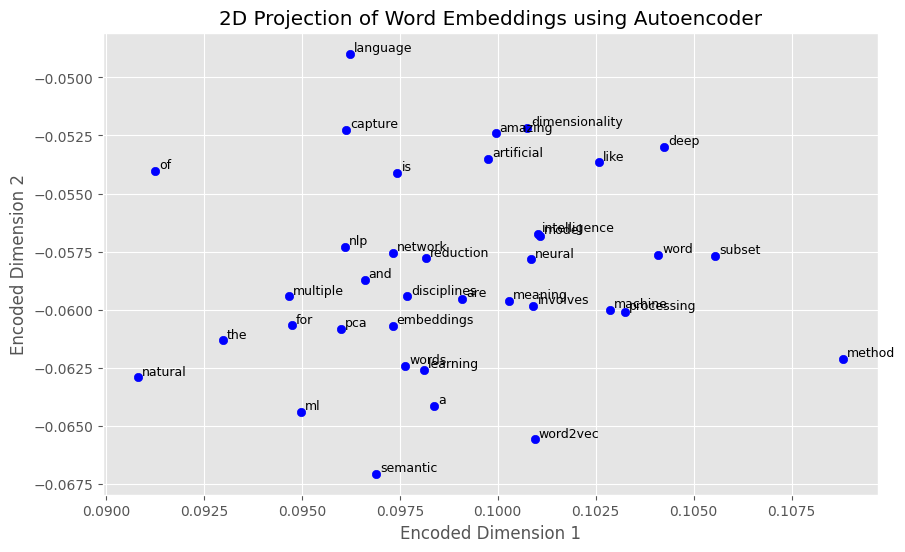

In [ ]:
# Sample corpus
documents = [
    "Natural language processing and machine learning are amazing.",
    "Word embeddings capture the semantic meaning of words.",
    "Deep learning is a subset of machine learning.",
    "Word2Vec is a neural network model for word embeddings.",
    "PCA is a method for dimensionality reduction.",
    "Artificial intelligence involves multiple disciplines like NLP and ML."
]

# Function to clean and tokenize text
def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

# Tokenize corpus
tokenized_corpus = [simple_tokenize(doc) for doc in documents]

# Train Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=3, min_count=1, workers=4)
words = list(word2vec_model.wv.index_to_key)
word_vectors = np.array([word2vec_model.wv[word] for word in words])

# Define Autoencoder class
class Autoencoder(nn.Module):
    def __init__(self, input_dim=100, hidden_dim=50, compressed_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, compressed_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(compressed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Convert word embeddings to PyTorch tensor
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
word_vectors_tensor = torch.tensor(word_vectors, dtype=torch.float32).to(device)

# Initialize Autoencoder
autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.01)

# Train Autoencoder
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    encoded, decoded = autoencoder(word_vectors_tensor)
    loss = criterion(decoded, word_vectors_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}")

# Extract compressed embeddings
word_vectors_autoencoded, _ = autoencoder(word_vectors_tensor)
word_vectors_autoencoded = word_vectors_autoencoded.detach().cpu().numpy()

# Plot the compressed word embeddings
plt.figure(figsize=(10, 6))
plt.scatter(word_vectors_autoencoded[:, 0], word_vectors_autoencoded[:, 1],
            c='blue')
for word, (x, y) in zip(words, word_vectors_autoencoded):
    plt.text(x+ 0.0001, y+ 0.0001, word, fontsize=9)
plt.xlabel("Encoded Dimension 1")
plt.ylabel("Encoded Dimension 2")
plt.title("2D Projection of Word Embeddings using Autoencoder")
plt.show()

In [ ]:
# Compute word similarity using cosine similarity
similarities = {}
for i, word1 in enumerate(words):
    for j, word2 in enumerate(words):
        if i < j:  # Avoid duplicate pairs
            similarity = 1 - cosine(word_vectors_autoencoded[i], word_vectors_autoencoded[j])
            similarities[(word1, word2)] = similarity

# Select the top 10 most similar word pairs based on cosine similarity
top_similar_words_autoencoded = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:10]

# Print the most similar word pairs
for pair, sim in top_similar_words_autoencoded:
    print(f"Words: {pair[0]} ↔ {pair[1]} | Similarity: {sim:.4f}")

Words: and ↔ disciplines | Similarity: 1.0000
Words: deep ↔ language | Similarity: 1.0000
Words: semantic ↔ natural | Similarity: 1.0000
Words: intelligence ↔ model | Similarity: 1.0000
Words: of ↔ network | Similarity: 1.0000
Words: of ↔ involves | Similarity: 1.0000
Words: for ↔ words | Similarity: 1.0000
Words: learning ↔ words | Similarity: 1.0000
Words: involves ↔ network | Similarity: 1.0000
Words: like ↔ amazing | Similarity: 1.0000


# Embedding using PCA

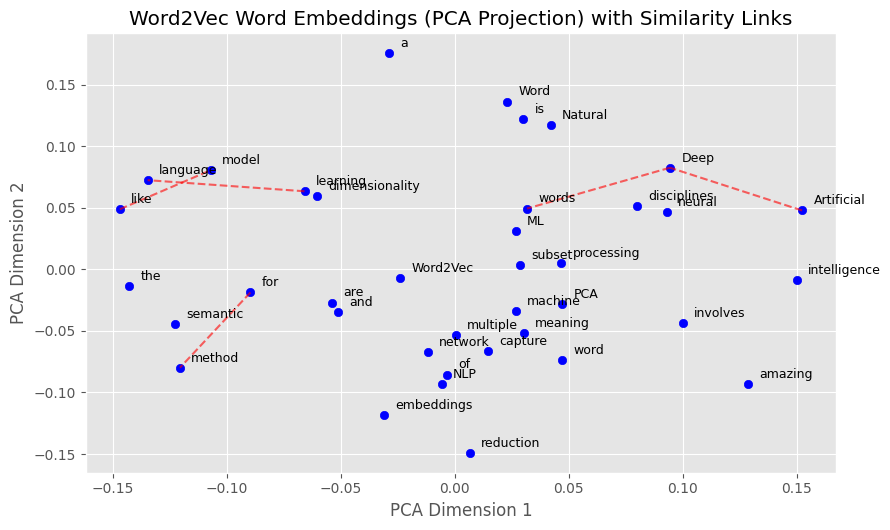

In [ ]:
# Define the corpus
#corpus = [
#    "We always come to Paris",
#    "The professor is from Australia",
#    "I live in Madrid",
#    "He comes from Taiwan",
#    "The capital of Turkey is Ankara"
#]

# Sample corpus
corpus = [
    "Natural language processing and machine learning are amazing",
    "Word embeddings capture the semantic meaning of words",
    "Deep learning is a subset of machine learning",
    "Word2Vec is a neural network model for word embeddings",
    "PCA is a method for dimensionality reduction",
    "Artificial intelligence involves multiple disciplines like NLP and ML"
]

# Tokenize the corpus
tokenized_corpus = [sentence.split() for sentence in corpus]

# Train a Word2Vec model with CBoW (default sg=0)
word2vec_model = Word2Vec(sentences=tokenized_corpus, vector_size=10, window=2, min_count=1, workers=4, sg=0)
word_vectors = np.array([word2vec_model.wv[word] for word in word2vec_model.wv.index_to_key])
word_labels = list(word2vec_model.wv.index_to_key)

# Reduce dimensions using PCA (2D projection)
pca = PCA(n_components=2)
word_vectors_2d_pca = pca.fit_transform(word_vectors)

# Compute word similarity using cosine similarity
similarities = {}
for i, word1 in enumerate(word_labels):
    for j, word2 in enumerate(word_labels):
        if i < j:  # Avoid duplicate pairs
            similarity = 1 - cosine(word_vectors[i], word_vectors[j])
            similarities[(word1, word2)] = similarity

# Select the top 5 most similar word pairs based on cosine similarity
top_similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:5]

# Plot PCA embeddings with similarity indications
plt.figure(figsize=(10, 6))
for i, word in enumerate(word_labels):
    plt.scatter(word_vectors_2d_pca[i, 0], word_vectors_2d_pca[i, 1], color='blue')
    plt.text(word_vectors_2d_pca[i, 0] + 0.005, word_vectors_2d_pca[i, 1] + 0.005, word, fontsize=9)

# Draw lines between the top similar words
for (word1, word2), sim in top_similar_words:
    i1, i2 = word_labels.index(word1), word_labels.index(word2)
    plt.plot(
        [word_vectors_2d_pca[i1, 0], word_vectors_2d_pca[i2, 0]],
        [word_vectors_2d_pca[i1, 1], word_vectors_2d_pca[i2, 1]],
        'r--', alpha=0.6, linewidth=1.5
    )

plt.title("Word2Vec Word Embeddings (PCA Projection) with Similarity Links")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.tight_layout(rect=(0, 0, 0.9, 0.9))
plt.show()
